In [71]:
import argparse
import matplotlib.pyplot as plt
import glob
import re
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches
from IPython.display import HTML, display
import json
import tabulate

# Data Exploration

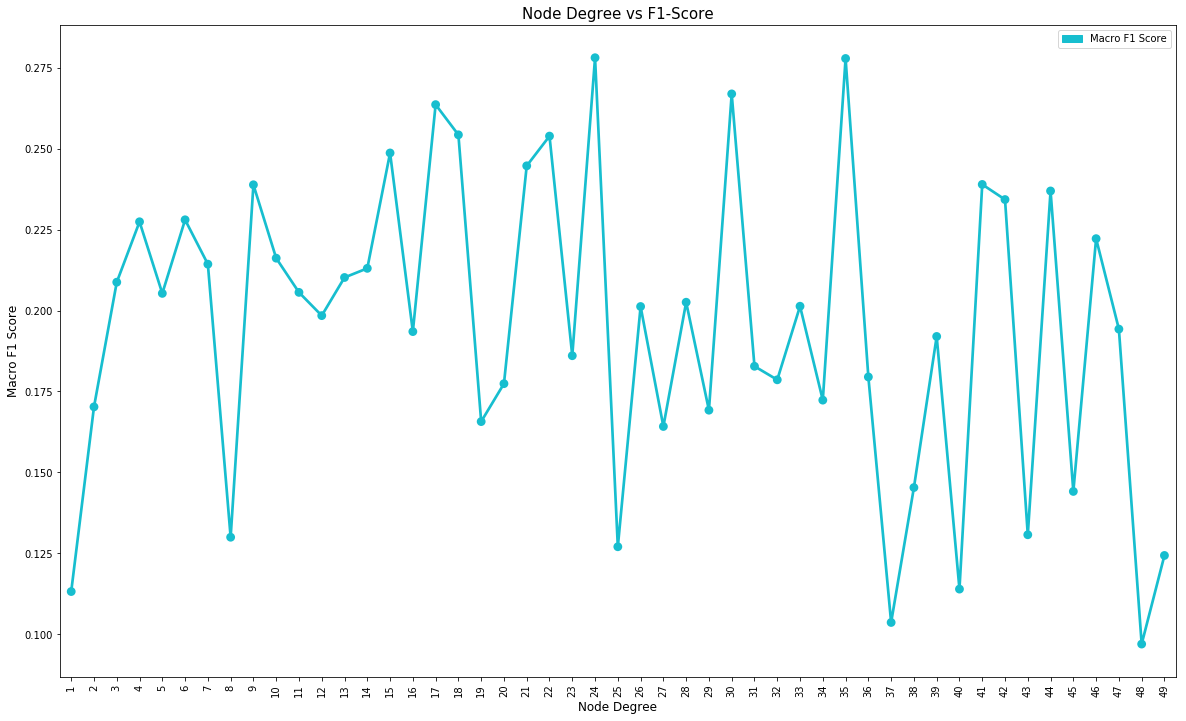

In [72]:
color = sns.color_palette()
plt.figure(figsize=(20, 12))
vals = {}

with open("degree_f1.json", "r") as f:
    data = json.load(f)
    #clean up data 
    for dp in data:
        vals[int(dp)] = data[dp]
x = []
y = []
for key in vals:
    if key < 50:
        x.append(key)
        y.append(vals[key])

sns.pointplot(x, y, alpha=0.1, color=color[9])
color_patch1 = mpatches.Patch(color=color[9], label="Macro F1 Score")
plt.legend(handles=[color_patch1])
plt.ylabel('Macro F1 Score', fontsize=12)
plt.xlabel('Node Degree', fontsize=12)
plt.title("Node Degree vs F1-Score", fontsize=15)
plt.xticks(rotation='vertical')
plt.show()

## Data Points Distribution Based on Node Degree 

In [89]:
x1 = []
y1 = []
with open("node_degree_distribution.json") as f:
    datapoint = json.load(f)
    
    for key, val in datapoint.items():
        x1.append(str(key))
        y1.append(len(val))
print("Node degree count distribution", sum(y1))
print (y1)


Node degree count distribution 10136
[1734, 1550, 1066, 762, 604, 476, 414, 326, 299, 257, 223, 189, 178, 135, 134, 118, 113, 89, 100, 96, 84, 74, 63, 53, 48, 48, 46, 41, 32, 34, 29, 32, 26, 38, 38, 20, 28, 24, 24, 20, 26, 14, 15, 20, 17, 15, 13, 13, 8, 16, 10, 12, 17, 11, 10, 11, 10, 7, 12, 9, 11, 8, 13, 11, 4, 5, 10, 10, 7, 3, 7, 6, 5, 6, 10, 6, 5, 4, 3, 3, 6, 4, 5, 2, 4, 7, 3, 5, 6, 3, 2, 2, 3, 1, 1, 4, 1, 1, 5, 3]


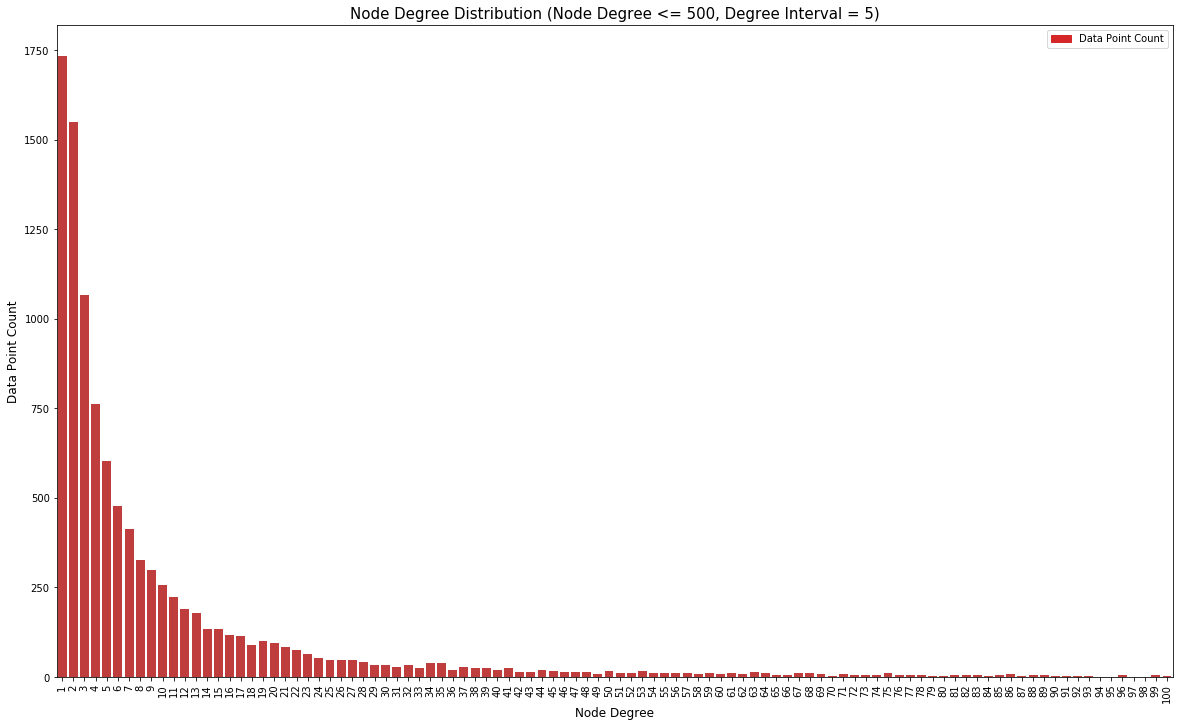

In [87]:
color = sns.color_palette()
plt.figure(figsize=(20,12))
sns.barplot(x1, y1,color=color[3], order=x1)
color_patch1 = mpatches.Patch(color=color[3], label="Data Point Count")
plt.legend(handles=[color_patch1])
plt.ylabel('Data Point Count', fontsize=12)
plt.xlabel('Node Degree', fontsize=12)
plt.title("Node Degree Distribution (Node Degree <= 500, Degree Interval = 5)", fontsize=15)
plt.xticks(rotation='vertical')
plt.show()

## Train & Test Based on Node Degree For The First 19 groups

['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19']
[0.1431254236742518, 0.17982889634135726, 0.13535910244797125, 0.1583247592058126, 0.15224401355880196, 0.12855633398251412, 0.16093534489567324, 0.10428484045226608, 0.12877214162577671, 0.14410820400656257, 0.23002316191815675, 0.11275969909365836, 0.10331881004149912, 0.12998273434849902, 0.09267020725494274, 0.0707974018318846, 0.0735559053740872, 0.10324786324786324, 0.11570532915360501]


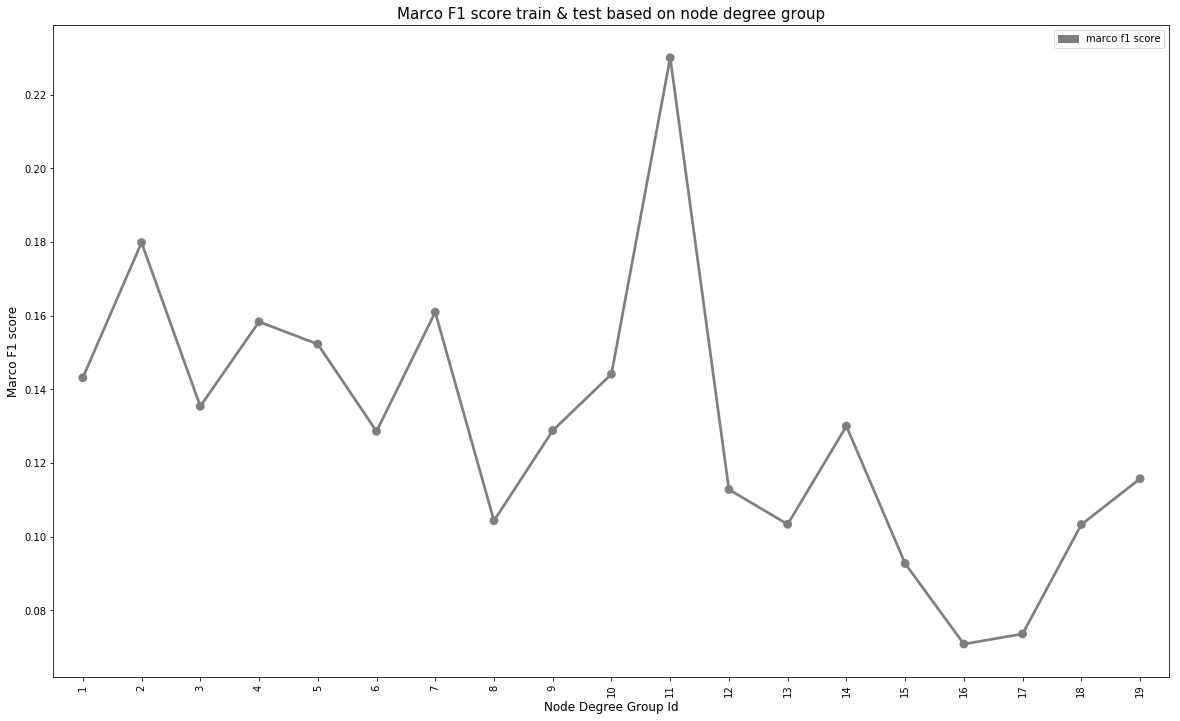

In [98]:
x2 = []
y2 = []

with open("degree_based_train.txt", "r") as file:
    for line in file:
        vals = line.split(" ")
        x2.append(vals[0])
        y2.append(float(vals[1]))

print(x2)
print(y2)

color = sns.color_palette()
plt.figure(figsize=(20,12))
sns.pointplot(x2, y2,color=color[7], order=x2)
color_patch1 = mpatches.Patch(color=color[7], label="marco f1 score")
plt.legend(handles=[color_patch1])
plt.ylabel('Marco F1 score', fontsize=12)
plt.xlabel('Node Degree Group Id', fontsize=12)
plt.title("Marco F1 score train & test based on node degree group", fontsize=15)
plt.xticks(rotation='vertical')
plt.show()


## Group Based Train & Test

### 10 Groups

['Group-1\n1-4\n', 'Group-2\n4-6\n', 'Group-3\n6-10\n', 'Group-4\n10-14\n', 'Group-5\n14-21\n', 'Group-6\n21-30\n', 'Group-7\n30-45\n', 'Group-8\n45-71\n', 'Group-9\n71-136\n', 'Group-10\n136-3992\n']
[0.10771817971339108, 0.14778024559025524, 0.15774622209881034, 0.15703112058293273, 0.17632921775264698, 0.17635187783414638, 0.1867510865272825, 0.17354937026415357, 0.2042760985600118, 0.17716195146804406]


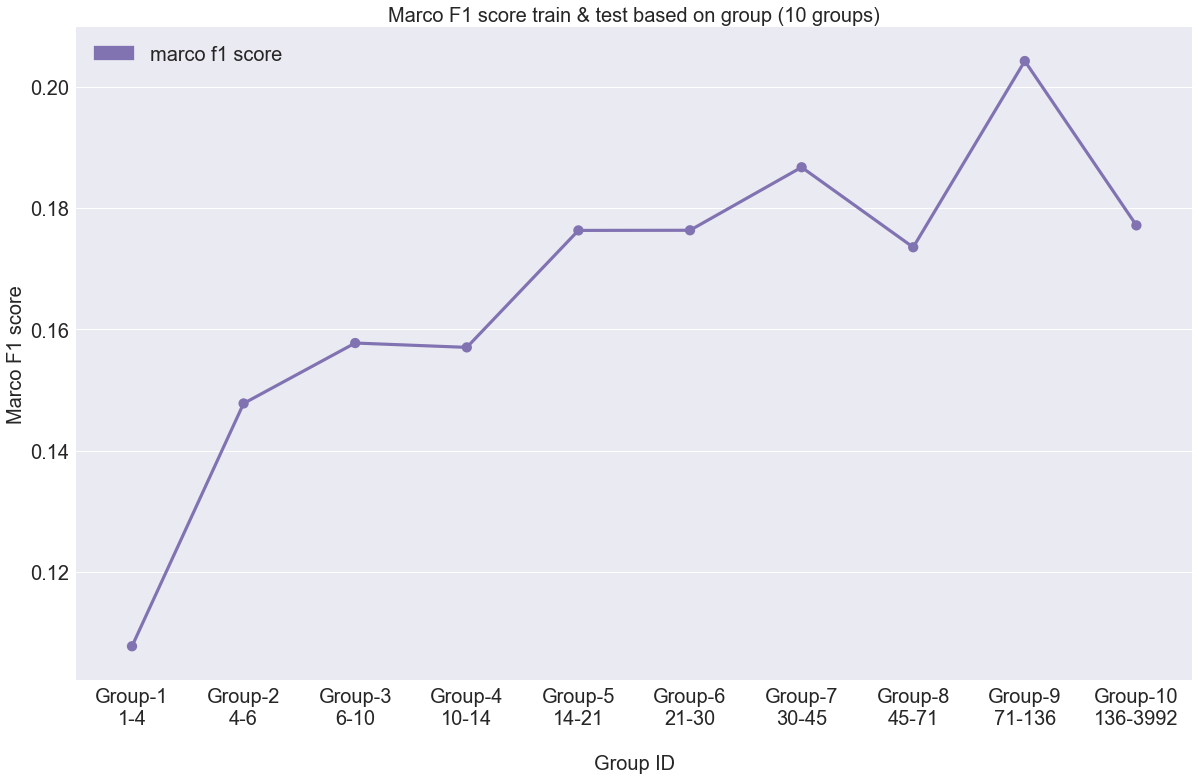

In [143]:
x3 = []
y3 = []

group_count = 1

with open("group_based_train_10.txt", "r") as file:
    for line in file:
        vals = line.split(" ")
        x3.append("Group-" + str(group_count) + "\n" + vals[1] + "-" + vals[2])
        y3.append(float(vals[0]))
        group_count += 1

print(x3)
print(y3)

with open("group_based_train_10_gs.txt", "r") as file:
    for line in file:
        vals = line.split(" ")
        
  
sns.set(font_scale=2)
color = sns.color_palette()
plt.figure(figsize=(20,12))
sns.pointplot(x3, y3,color=color[3], order=x3)
color_patch1 = mpatches.Patch(color=color[3], label="marco f1 score")
plt.legend(handles=[color_patch1])
plt.ylabel('Marco F1 score', fontsize=20)
plt.xlabel('Group ID', fontsize=20)
plt.title("Marco F1 score train & test based on group (10 groups)", fontsize=20)
plt.xticks(rotation='horizontal')
plt.show()

## GraphSage